# IMFACT vs Native Guide vs Wachter on FaultDetectionA

This notebook compares three counterfactual methods on **FaultDetectionA**:
- `imfact_cf` from `cfts.cf_imfact.imfact`
- `native_guide_uni_cf` from `cfts.cf_native_guide.native_guide`
- `wachter_gradient_cf` from `cfts.cf_wachter.wachter`

For IMFACT, it uses ablation-selected settings:
- `method="variance"`
- `n_nuns=3`
- `nun_switch="cycle"`

The notebook reports counterfactual quality metrics (`L2`, `DTW`, `sparsity`, `validity`) and visualizes UMAP projections where UMAP is fit on background dataset points and then used to transform query/counterfactual points.

In [1]:
from __future__ import annotations

from pathlib import Path
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import umap
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_imfact.imfact import imfact_cf
from cfts.cf_native_guide.native_guide import native_guide_uni_cf
from cfts.cf_wachter.wachter import wachter_gradient_cf
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_counterfactual,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
def to_channel_first(sample: np.ndarray) -> np.ndarray:
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    raise ValueError(f"Unsupported sample shape: {arr.shape}")


def to_class_index(label) -> int:
    label_arr = np.asarray(label)
    if label_arr.ndim == 0:
        return int(label_arr)
    return int(np.argmax(label_arr))


def predict_scores(model: torch.nn.Module, sample: np.ndarray, device: torch.device) -> np.ndarray:
    ts = torch.tensor(sample, dtype=torch.float32, device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def model_wrapper_factory(model: torch.nn.Module, device: torch.device):
    def wrapped(ts: np.ndarray) -> np.ndarray:
        return predict_scores(model, np.asarray(ts, dtype=np.float32), device)

    return wrapped


def select_correct_indices(model: torch.nn.Module, dataset, max_count: int, device: torch.device) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def infer_target_class(scores: np.ndarray) -> int:
    order = np.argsort(scores)[::-1]
    return int(order[1])


def run_imfact_variance(sample: np.ndarray, dataset, model: torch.nn.Module, target_class: int):
    return imfact_cf(
        sample=sample,
        dataset=dataset,
        model=model,
        method="variance",
        target_class=target_class,
        step=0.05,
        max_iter=200,
        max_imfs=10,
        n_nuns=3,
        nun_switch="cycle",
        verbose=False,
    )


def run_native_guide(sample: np.ndarray, dataset, model: torch.nn.Module, target_class: int):
    return native_guide_uni_cf(sample=sample, model=model, target_class=target_class, dataset=dataset)


def run_wachter(sample: np.ndarray, dataset, model: torch.nn.Module, target_class: int):
    return wachter_gradient_cf(
        sample=sample,
        dataset=dataset,
        model=model,
        target=target_class,
        max_cfs=400,
        distance="euclidean",
        verbose=False,
    )


def run_glacier(sample: np.ndarray, dataset, model: torch.nn.Module, target_class: int):
    from cfts.cf_glacier.glacier import glacier_cf
    return glacier_cf(
        sample=sample, dataset=dataset, model=model,
        target_class=target_class, max_iterations=500, verbose=False,
    )


_MASCOTS_EXPLAINER_CACHE = None


def _get_mascots_explainer(dataset, model: torch.nn.Module):
    global _MASCOTS_EXPLAINER_CACHE
    if _MASCOTS_EXPLAINER_CACHE is not None:
        return _MASCOTS_EXPLAINER_CACHE

    from cfts.cf_mascots._borf_explainer import BorfExplainer
    from cfts.cf__abstract.abstract import ensure_ncl, subsample_dataset, detach_to_numpy
    from cfts.cf__abstract.abstract import numpy_to_torch

    mascots_device = next(model.parameters()).device
    ds = subsample_dataset(dataset, 50)
    dummy_sample = np.asarray(dataset[0][0], dtype=np.float32)
    _, ts, _ = ensure_ncl(dummy_sample, ds)

    def _pred_fn(X):
        X_t = numpy_to_torch(np.asarray(X, dtype=np.float32), mascots_device)
        with torch.no_grad():
            logits = detach_to_numpy(model(X_t))
        return np.argmax(logits, axis=1).astype(int)

    def _pred_proba_fn(X):
        X_t = numpy_to_torch(np.asarray(X, dtype=np.float32), mascots_device)
        with torch.no_grad():
            logits = detach_to_numpy(model(X_t))
        e = np.exp(logits - logits.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    # Compact borf config: small window sizes suitable for long series (L=5120)
    compact_config = [
        {"window_size": ws, "stride": 1, "dilation": 1, "word_length": 4, "alphabet_size": 3}
        for ws in [16, 64, 256]
    ]
    print("[mascots] building BorfExplainer (once) ...")
    try:
        import numba
        _prev_threads = numba.get_num_threads()
        numba.set_num_threads(1)
    except Exception:
        _prev_threads = None
    explainer = BorfExplainer(_pred_fn, _pred_proba_fn, borf_config=compact_config)
    explainer.build(ts, seed=42)
    if _prev_threads is not None:
        try:
            numba.set_num_threads(_prev_threads)
        except Exception:
            pass
    print("[mascots] BorfExplainer ready.")
    _MASCOTS_EXPLAINER_CACHE = explainer
    return _MASCOTS_EXPLAINER_CACHE


def run_mascots(sample: np.ndarray, dataset, model: torch.nn.Module, target_class: int):
    from cfts.cf_mascots.mascots import mascots_cf
    explainer = _get_mascots_explainer(dataset, model)
    return mascots_cf(
        sample=sample, model=model,
        target_class=target_class, dataset=dataset,
        max_iter=100, verbose=False,
        prebuilt_explainer=explainer,
    )

In [3]:
# Load FaultDetectionA and the matching pretrained model.
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FaultDetectionA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FaultDetectionA", split="test")

output_classes = dataset_train.y_shape[1]
dataset_length = int(dataset_train.X_shape[2])

models_dir = REPO_ROOT / "models"
candidate_model_paths = [
    models_dir / "simple_cnn_faultdetectiona_3_len5120.pth",
    models_dir / "simple_cnn_faultdetectiona_3.pth",
]

model = None
last_error = None

for model_path in candidate_model_paths:
    if not model_path.exists():
        continue

    state = torch.load(model_path, map_location=device)

    try:
        candidate_model = SimpleCNN(
            output_channels=output_classes,
            input_length=dataset_length,
        ).to(device)
        candidate_model.load_state_dict(state)
        model = candidate_model
        print(f"Loaded model: {model_path}")
        break
    except RuntimeError as exc:
        last_error = exc
        print(f"Skipping incompatible checkpoint {model_path}: {exc}")

if model is None:
    available = [str(path) for path in candidate_model_paths if path.exists()]
    if not available:
        raise FileNotFoundError(
            "Could not find FaultDetectionA checkpoint. Expected one of: "
            + ", ".join(str(path) for path in candidate_model_paths)
        )
    raise RuntimeError(
        "Found checkpoints but none matched model architecture. "
        f"Dataset length={dataset_length}. Last load error: {last_error}"
    )

model.eval()

with torch.no_grad():
    y_true = []
    y_pred = []
    for sample, label in dataset_test:
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        y_true.append(to_class_index(label))
        y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Model input length set to: {dataset_length}")
print(f"Test macro F1: {test_f1:.4f}")

reference_count = min(256, len(dataset_train))
reference_data = np.stack(
    [np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(reference_count)],
    axis=0,
)
print(f"Reference data shape: {reference_data.shape}")

Loaded model: /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_faultdetectiona_3_len5120.pth
Train size: 10912 | Test size: 2728
Model input length set to: 5120
Test macro F1: 0.9989
Reference data shape: (256, 1, 5120)


In [4]:
# Evaluate methods on correctly classified samples.
N_SAMPLES = 10
selected_indices = select_correct_indices(model, dataset_test, max_count=N_SAMPLES, device=device)
print(f"Using {len(selected_indices)} correctly classified samples.")

model_for_metrics = model_wrapper_factory(model, device)
records = []
all_cf_outputs = {}

for i, idx in enumerate(selected_indices):
    print(f"[{i + 1}/{len(selected_indices)}] sample idx={idx}", flush=True)
    sample, label = dataset_test[idx]
    sample = np.asarray(sample, dtype=np.float32)

    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    runs = {
        "imfact_variance_nun3": lambda: run_imfact_variance(sample, dataset_test, model, target_class),
        "native_guide": lambda: run_native_guide(sample, dataset_test, model, target_class),
        "wachter": lambda: run_wachter(sample, dataset_test, model, target_class),
        "glacier": lambda: run_glacier(sample, dataset_test, model, target_class),
        "mascots": lambda: run_mascots(sample, dataset_test, model, target_class),
    }

    all_cf_outputs[idx] = {"sample": sample, "true_label": true_label, "target_class": target_class}

    for method_name, runner in runs.items():
        base_record = {
            "sample_idx": idx,
            "method": method_name,
            "true_label": true_label,
            "pred_orig": pred_orig,
            "target_class": target_class,
            "pred_cf": None,
            "success": False,
            "l2_norm": np.nan,
            "dtw_proximity": np.nan,
            "normalized_distance": np.nan,
            "sparsity": np.nan,
            "range_validity": np.nan,
            "autocorr": np.nan,
            "keane_validity": np.nan,
            "keane_proximity": np.nan,
            "keane_compactness": np.nan,
            "validity": 0.0,
            "euclidean_dist_zscore": np.nan,
            "manhattan_distance": np.nan,
            "l0_norm": np.nan,
            "compactness": np.nan,
            "elapsed": np.nan,
            "error": None,
        }
        start_time = time.time()
        try:
            cf, pred_cf_scores = runner()
        except Exception as exc:
            elapsed = time.time() - start_time
            records.append({**base_record, "elapsed": elapsed, "error": f"{type(exc).__name__}: {exc}"})
            continue
        elapsed = time.time() - start_time

        if cf is None or pred_cf_scores is None:
            records.append({**base_record, "elapsed": elapsed, "error": "Method returned None"})
            continue

        cf = np.asarray(cf, dtype=np.float32)
        pred_cf = int(np.argmax(np.asarray(pred_cf_scores).reshape(-1)))
        success = pred_cf == target_class

        sample_cf = to_channel_first(sample)
        cf_cf = to_channel_first(cf)

        keane = evaluate_keane_metrics(
            original_ts_list=sample_cf,
            counterfactual_ts_list=cf_cf,
            model=model_for_metrics,
            target_classes=int(target_class),
        )
        extra_metrics = evaluate_counterfactual(sample_cf, cf_cf, dtw_max_length=None)

        records.append({
            **base_record,
            "elapsed": elapsed,
            "pred_cf": pred_cf,
            "success": bool(success),
            "l2_norm": float(l2_distance(sample_cf, cf_cf)),
            "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
            "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
            "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
            "range_validity": float(feature_range_validity(cf_cf, reference_data)),
            "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
            "keane_validity": float(keane["validity"]),
            "keane_proximity": float(keane["proximity"]),
            "keane_compactness": float(keane["compactness"]),
            "validity": float(prediction_change(sample_cf, cf_cf, model_for_metrics, target_class=target_class)),
            "euclidean_dist_zscore": extra_metrics["euclidean_dist_zscore"],
            "manhattan_distance": extra_metrics["manhattan_distance"],
            "l0_norm": extra_metrics["l0_norm"],
            "compactness": extra_metrics["compactness"],
        })

        all_cf_outputs[idx][method_name] = cf

results_df = pd.DataFrame(records)
results_df.head()

Using 10 correctly classified samples.
[1/10] sample idx=0
[mascots] building BorfExplainer (once) ...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


[mascots] BorfExplainer ready.
[2/10] sample idx=1
[3/10] sample idx=2
[4/10] sample idx=3
[5/10] sample idx=4
[6/10] sample idx=5
[7/10] sample idx=6
[8/10] sample idx=7
[9/10] sample idx=8
[10/10] sample idx=9


,sample_idx,method,true_label,pred_orig,target_class,pred_cf,success,l2_norm,dtw_proximity,normalized_distance,...,keane_validity,keane_proximity,keane_compactness,validity,euclidean_dist_zscore,manhattan_distance,l0_norm,compactness,elapsed,error
0,0,imfact_variance_nun3,1,1,0,0,True,7.280914,5.675120,0.047295,...,1.0,7.280914,0.136719,1.0,60.195389,327.472687,5094,0.136719,1.278749,None
1,0,native_guide,1,1,0,0,True,18.368065,13.827995,0.119313,...,1.0,18.368065,0.561719,1.0,151.859070,501.593018,2375,0.561719,7.457491,None
2,0,wachter,1,1,0,1,False,0.034677,0.034676,0.000225,...,0.0,0.034677,1.000000,0.0,0.286690,1.119395,4427,1.000000,8.537890,None
3,0,glacier,1,1,0,0,True,7.789913,6.639297,0.050601,...,1.0,7.789913,0.693750,1.0,64.403564,159.082581,5119,0.693750,3.754392,None
4,0,mascots,1,1,0,2,False,2.261855,1.352796,0.014692,...,0.0,2.261855,0.864258,0.0,18.700024,50.023788,864,0.864258,231.302195,None


In [5]:
# Summarize quality metrics.
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method", dropna=False)
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
        elapsed_mean=("elapsed", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method", dropna=False)
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_validity_mean=("keane_validity", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
            euclidean_dist_zscore_mean=("euclidean_dist_zscore", "mean"),
            manhattan_distance_mean=("manhattan_distance", "mean"),
            l0_norm_mean=("l0_norm", "mean"),
            compactness_mean=("compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)

summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)
summary_df["success_rate"] = 100.0 * summary_df["success_rate"]
summary_df["validity_mean"] = summary_df["validity_mean"].fillna(0.0)

summary_df.sort_values("method")

,method,n_total,n_successful,success_rate,validity_mean,elapsed_mean,l2_norm_mean,dtw_proximity_mean,normalized_distance_mean,sparsity_mean,range_validity_mean,autocorr_mean,keane_validity_mean,keane_proximity_mean,keane_compactness_mean,euclidean_dist_zscore_mean,manhattan_distance_mean,l0_norm_mean,compactness_mean
0,glacier,10,10,100.0,1.0,3.398960,8.355393,6.791708,0.052756,0.000352,0.953281,0.964638,1.0,8.355393,0.63625,58.068547,187.939442,5118.2,0.63625
1,imfact_variance_nun3,10,10,100.0,1.0,1.533302,10.858219,7.503145,0.067142,0.001387,0.969629,0.926257,1.0,10.858219,0.10334,71.185158,495.591705,5112.9,0.10334
2,mascots,10,0,0.0,0.0,968.218985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,native_guide,10,10,100.0,1.0,13.022885,20.748402,14.509113,0.131128,0.402676,0.925566,0.629623,1.0,20.748402,0.42832,143.818900,682.776184,3058.3,0.42832
4,wachter,10,3,30.0,0.3,5.356846,17.653383,13.439391,0.083272,0.000000,0.959635,0.790462,1.0,17.653383,0.13418,89.485724,716.145101,5120.0,0.13418


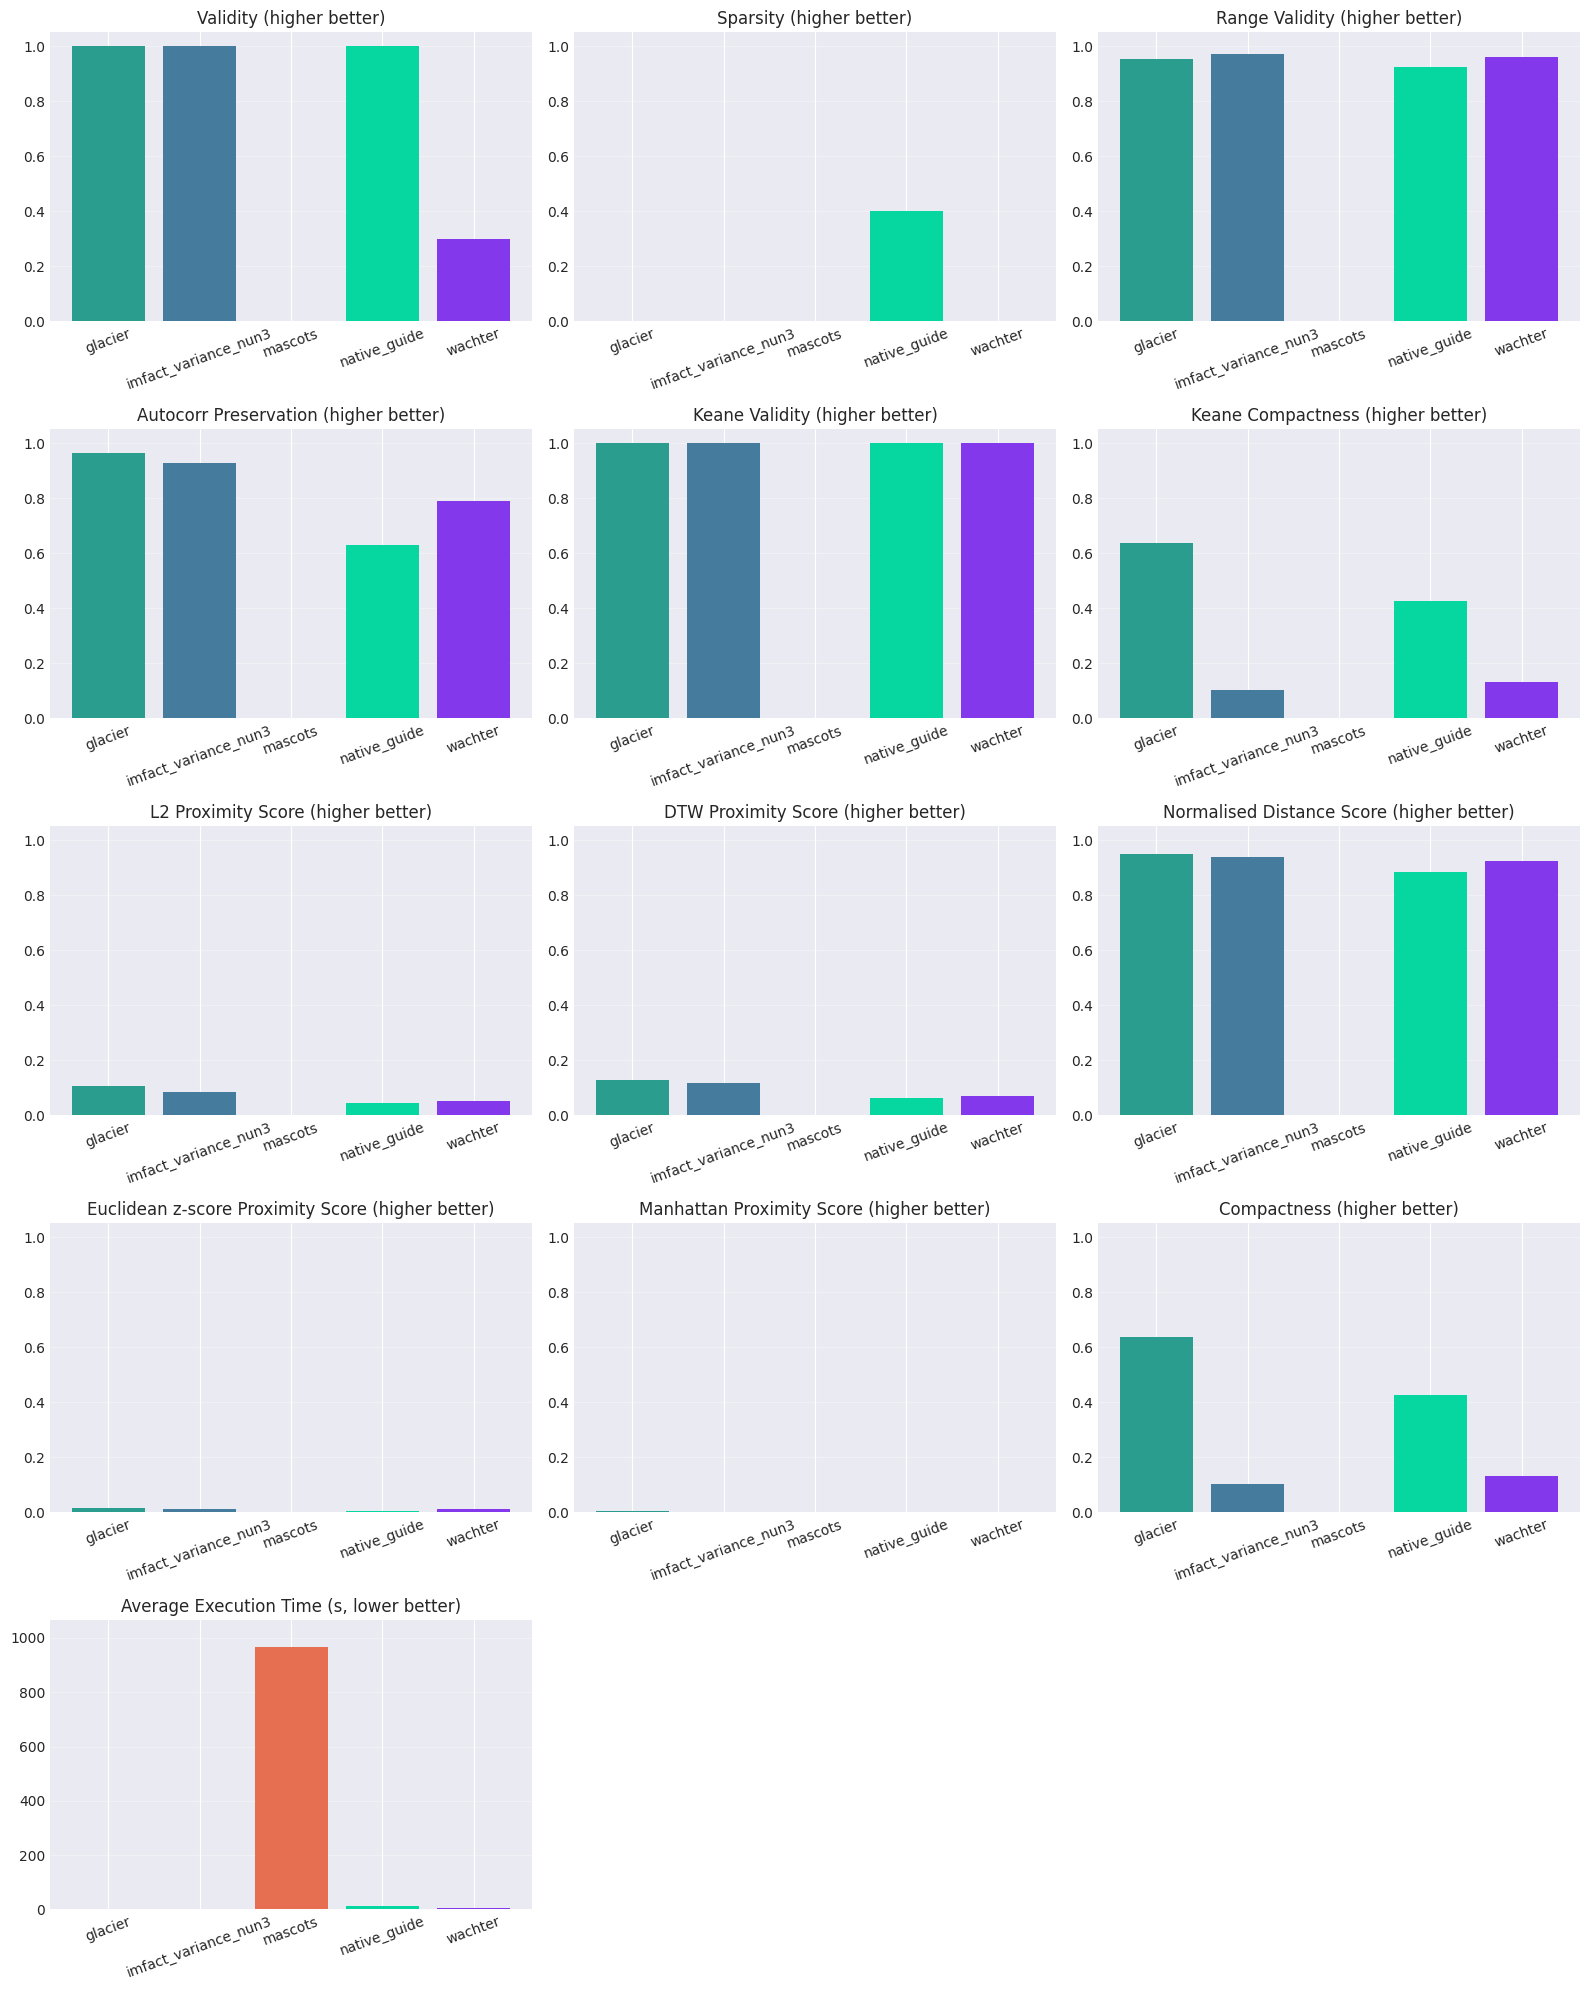

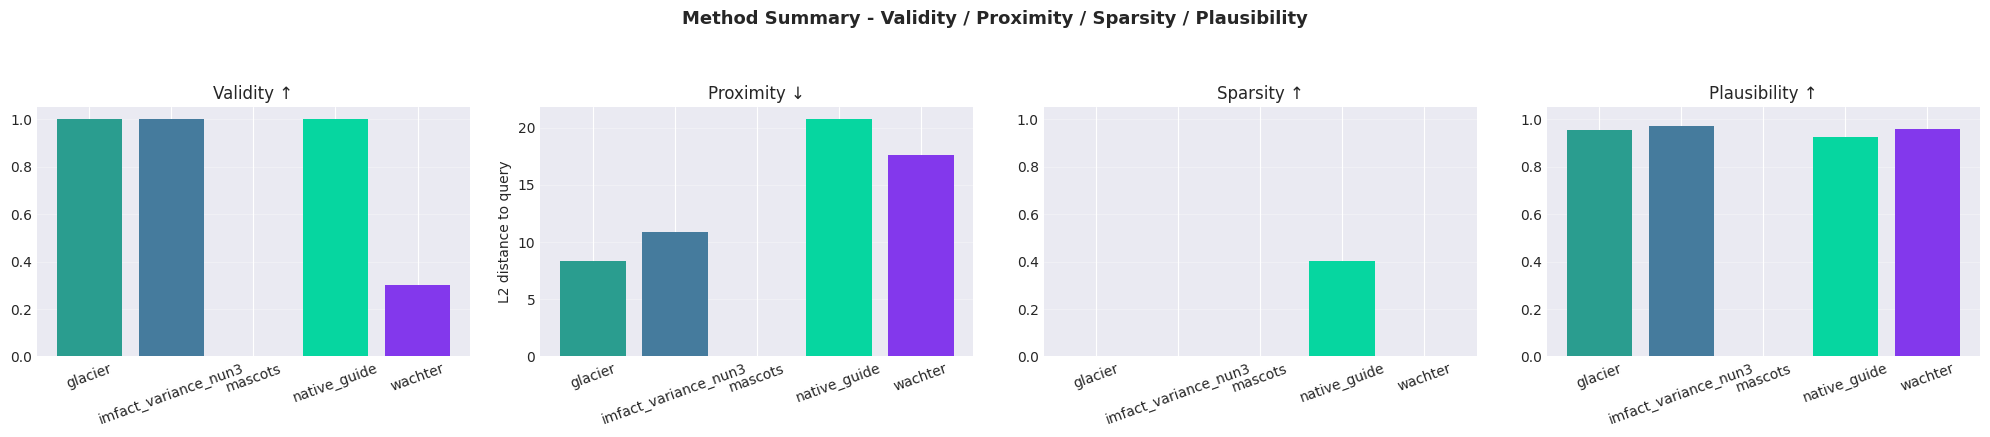

In [6]:
colors = ["#2a9d8f", "#457b9d", "#e76f51", "#06d6a0", "#8338ec"]
plot_df = summary_df.sort_values("method").copy()
methods = plot_df["method"].tolist()

def _bar(ax, vals, title, ylim=(0, 1.05)):
    ax.bar(methods, vals, color=colors[:len(methods)])
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, axis="y", alpha=0.3)

l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"])
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"])
norm_dist_score = 1.0 / (1.0 + plot_df["normalized_distance_mean"])
keane_prox_score = 1.0 / (1.0 + plot_df["keane_proximity_mean"])
zscore_score = 1.0 / (1.0 + plot_df["euclidean_dist_zscore_mean"])
manhattan_score = 1.0 / (1.0 + plot_df["manhattan_distance_mean"])
l0_norm_score = 1.0 / (1.0 + plot_df["l0_norm_mean"])

time_max = max(float(plot_df["elapsed_mean"].fillna(0).max()) * 1.1, 0.01)

fig, axes = plt.subplots(5, 3, figsize=(16, 20))

_bar(axes[0, 0], plot_df["validity_mean"], "Validity (higher better)")
_bar(axes[0, 1], plot_df["sparsity_mean"], "Sparsity (higher better)")
_bar(axes[0, 2], plot_df["range_validity_mean"], "Range Validity (higher better)")
_bar(axes[1, 0], plot_df["autocorr_mean"], "Autocorr Preservation (higher better)")
_bar(axes[1, 1], plot_df["keane_validity_mean"], "Keane Validity (higher better)")
_bar(axes[1, 2], plot_df["keane_compactness_mean"], "Keane Compactness (higher better)")
_bar(axes[2, 0], l2_score, "L2 Proximity Score (higher better)")
_bar(axes[2, 1], dtw_score, "DTW Proximity Score (higher better)")
_bar(axes[2, 2], norm_dist_score, "Normalised Distance Score (higher better)")
_bar(axes[3, 0], zscore_score, "Euclidean z-score Proximity Score (higher better)")
_bar(axes[3, 1], manhattan_score, "Manhattan Proximity Score (higher better)")
_bar(axes[3, 2], plot_df["compactness_mean"], "Compactness (higher better)")
_bar(axes[4, 0], plot_df["elapsed_mean"], "Average Execution Time (s, lower better)", ylim=(0, time_max))
axes[4, 1].axis("off")
axes[4, 2].axis("off")

plt.tight_layout()
plt.show()

# Canonical CF-evaluation dimensions: validity (higher better), proximity
# (lower better), sparsity (higher better), plausibility (higher better).
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 4.5))

axes2[0].bar(methods, plot_df["validity_mean"], color=colors[: len(methods)])
axes2[0].set_title("Validity \u2191")
axes2[0].set_ylim(0, 1.05)
axes2[0].tick_params(axis="x", rotation=20)
axes2[0].grid(True, axis="y", alpha=0.3)

axes2[1].bar(methods, plot_df["l2_norm_mean"], color=colors[: len(methods)])
axes2[1].set_title("Proximity \u2193")
axes2[1].set_ylabel("L2 distance to query")
axes2[1].tick_params(axis="x", rotation=20)
axes2[1].grid(True, axis="y", alpha=0.3)

axes2[2].bar(methods, plot_df["sparsity_mean"], color=colors[: len(methods)])
axes2[2].set_title("Sparsity \u2191")
axes2[2].set_ylim(0, 1.05)
axes2[2].tick_params(axis="x", rotation=20)
axes2[2].grid(True, axis="y", alpha=0.3)

axes2[3].bar(methods, plot_df["range_validity_mean"], color=colors[: len(methods)])
axes2[3].set_title("Plausibility \u2191")
axes2[3].set_ylim(0, 1.05)
axes2[3].tick_params(axis="x", rotation=20)
axes2[3].grid(True, axis="y", alpha=0.3)

fig2.suptitle("Method Summary - Validity / Proximity / Sparsity / Plausibility", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

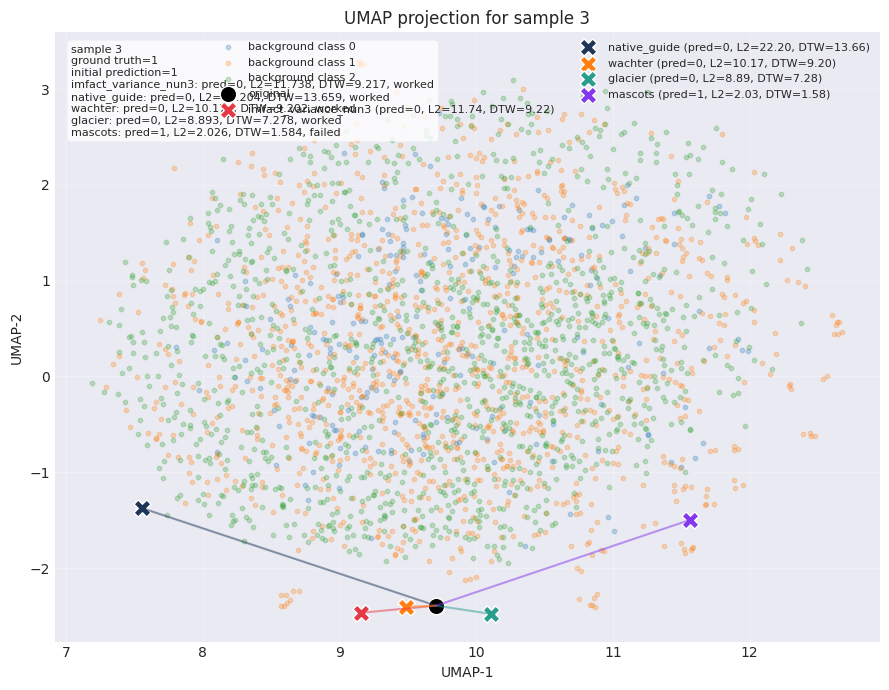

In [7]:
# UMAP projection for one representative evaluated sample.
background_data = np.stack([to_channel_first(dataset_test[i][0]).reshape(-1) for i in range(len(dataset_test))], axis=0)
background_labels = np.array([to_class_index(dataset_test[i][1]) for i in range(len(dataset_test))])

method_order = ["imfact_variance_nun3", "native_guide", "wachter", "glacier", "mascots"]

sample_success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
 )

full_success_indices = [
    int(sample_idx) for sample_idx, count in sample_success_counts.items() if int(count) == len(method_order)
 ]

if full_success_indices:
    rep_idx = full_success_indices[0]
else:
    rep_idx = int(sample_success_counts.index[0])

rep_payload = all_cf_outputs[rep_idx]
rep_sample = to_channel_first(rep_payload["sample"]).reshape(1, -1)

n_neighbors = min(15, max(2, len(background_data) - 1))
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=0.15,
    metric="euclidean",
    random_state=42,
 )
background_emb = reducer.fit_transform(background_data)
sample_emb = reducer.transform(rep_sample)[0]

method_colors = {
    "imfact_variance_nun3": "#e63946",
    "native_guide": "#1d3557",
    "wachter": "#ff7f11",
    "glacier": "#2a9d8f",
    "mascots": "#8338ec",
}

sample_results = results_df[results_df["sample_idx"] == rep_idx]
metric_lookup = {
    row["method"]: {
        "l2": float(row["l2_norm"]),
        "dtw": float(row["dtw_proximity"]),
        "success": bool(row["success"]),
        "pred": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0] if len(sample_results) else None
true_label = int(orig_row["true_label"]) if orig_row is not None else to_class_index(rep_payload["true_label"] if "true_label" in rep_payload else 0)
initial_pred = int(orig_row["pred_orig"]) if orig_row is not None else None

fig, ax = plt.subplots(figsize=(9, 7))

for class_id in np.unique(background_labels):
    mask = background_labels == class_id
    ax.scatter(
        background_emb[mask, 0],
        background_emb[mask, 1],
        s=10,
        alpha=0.25,
        label=f"background class {class_id}",
    )

ax.scatter(sample_emb[0], sample_emb[1], s=140, c="black", marker="o", edgecolors="white", label="original")

annotation_lines = [f"sample {rep_idx}", f"ground truth={true_label}", f"initial prediction={initial_pred}"]

for method_name in method_order:
    cf = rep_payload.get(method_name)
    if cf is None:
        continue
    cf_flat = to_channel_first(cf).reshape(1, -1)
    cf_emb = reducer.transform(cf_flat)[0]
    metrics = metric_lookup.get(method_name, {})
    l2_val = metrics.get("l2", np.nan)
    dtw_val = metrics.get("dtw", np.nan)
    worked = metrics.get("success", False)
    pred_cf = metrics.get("pred", None)

    annotation_lines.append(f"{method_name}: pred={pred_cf}, L2={l2_val:.3f}, DTW={dtw_val:.3f}, {'worked' if worked else 'failed'}")

    ax.scatter(
        cf_emb[0],
        cf_emb[1],
        s=150,
        c=method_colors[method_name],
        marker="X",
        edgecolors="white",
        linewidths=1.0,
        label=f"{method_name} (pred={pred_cf}, L2={l2_val:.2f}, DTW={dtw_val:.2f})",
    )
    ax.plot([sample_emb[0], cf_emb[0]], [sample_emb[1], cf_emb[1]], color=method_colors[method_name], alpha=0.5)

ax.text(
    0.02,
    0.98,
    "\n".join(annotation_lines),
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
)

ax.set_title(f"UMAP projection for sample {rep_idx}")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

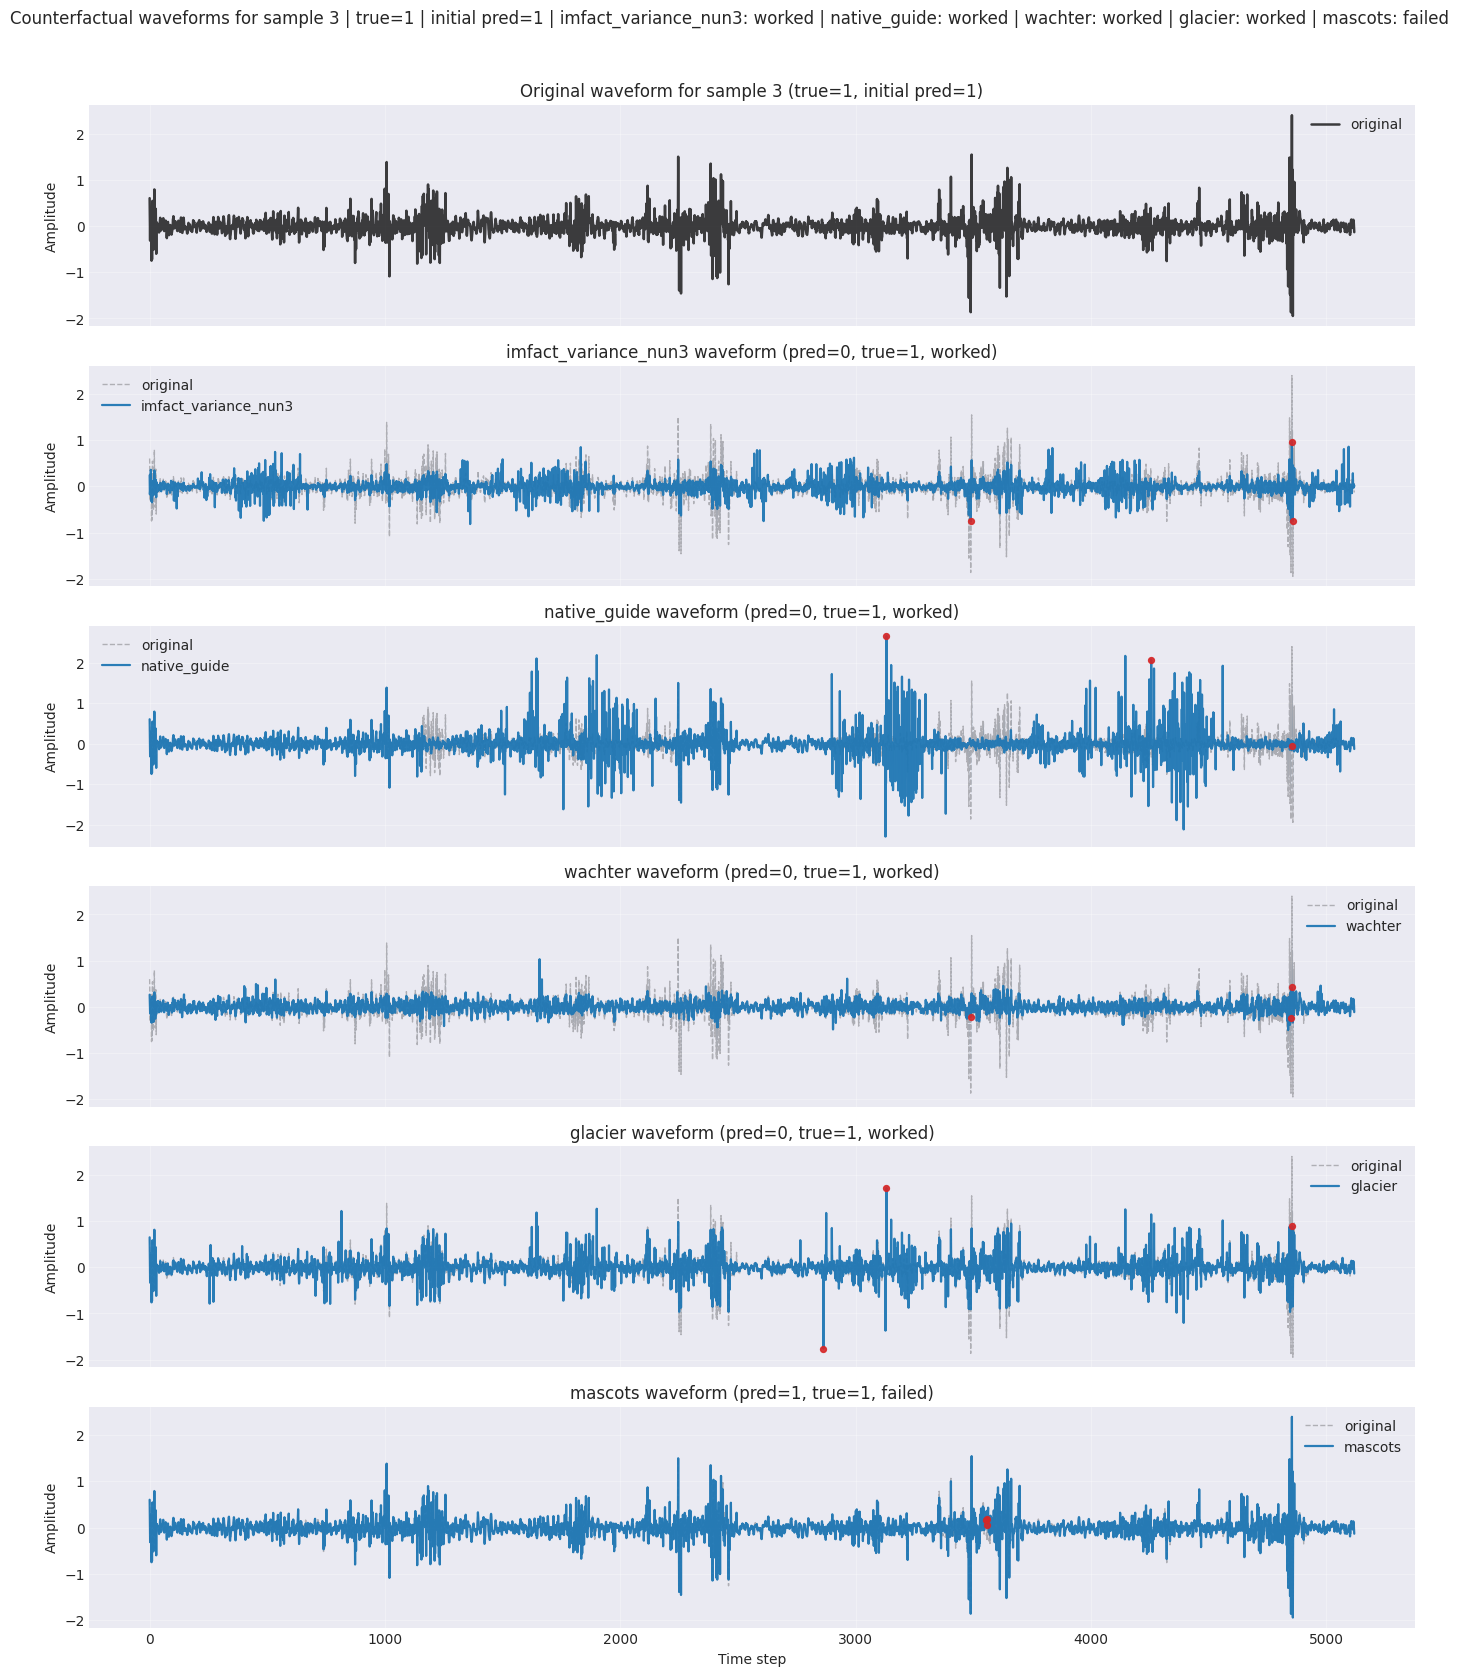

In [8]:
# Signal-space comparison with subplots for the same representative sample.
method_order = ["imfact_variance_nun3", "native_guide", "wachter", "glacier", "mascots"]

sample_success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
 )

full_success_indices = [
    int(sample_idx) for sample_idx, count in sample_success_counts.items() if int(count) == len(method_order)
 ]

if full_success_indices:
    rep_idx = full_success_indices[0]
else:
    rep_idx = int(sample_success_counts.index[0])

rep_payload = all_cf_outputs[rep_idx]
x = to_channel_first(rep_payload["sample"])[0]
x_axis = np.arange(len(x))

n_rows = 1 + len(method_order)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 2.8 * n_rows), sharex=True)

# Build success and prediction lookup for this sample from evaluation records.
sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0] if len(sample_results) else None
true_label = int(orig_row["true_label"]) if orig_row is not None else None
initial_pred = int(orig_row["pred_orig"]) if orig_row is not None else None

status_parts = []
for method_name in method_order:
    worked = info_lookup.get(method_name, {}).get("success", False)
    status_parts.append(f"{method_name}: {'worked' if worked else 'failed'}")

fig.suptitle(
    f"Counterfactual waveforms for sample {rep_idx} | true={true_label} | initial pred={initial_pred} | " + " | ".join(status_parts),
    fontsize=12,
    y=0.995,
 )

# Top panel: original only.
axes[0].plot(x, label="original", color="black", linewidth=1.8, alpha=0.75)
axes[0].set_title(f"Original waveform for sample {rep_idx} (true={true_label}, initial pred={initial_pred})")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# Remaining panels: one method per subplot.
for i, method_name in enumerate(method_order, start=1):
    ax = axes[i]
    cf = rep_payload.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred", None)

    ax.plot(x, label="original", color="black", linewidth=1.0, linestyle="--", alpha=0.25)
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no counterfactual available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_line = to_channel_first(cf)[0]
        ax.plot(cf_line, label=method_name, linewidth=1.6, alpha=0.95, color="#1f77b4")
        ax.fill_between(x_axis, x, cf_line, color="#1f77b4", alpha=0.18, linewidth=0)
        diff_abs = np.abs(cf_line - x)
        top_idx = np.argsort(diff_abs)[-3:] if diff_abs.size >= 3 else np.arange(diff_abs.size)
        ax.scatter(x_axis[top_idx], cf_line[top_idx], s=18, color="#d62728", alpha=0.9, zorder=4)

    ax.set_title(f"{method_name} waveform (pred={pred_cf}, true={true_label}, {'worked' if worked else 'failed'})")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()